In [1]:
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow_probability as tfp
from utils import CORR, UNCORR, CORR_FT, UNCORR_FT, plot_availability_heatmap
from gaussian_process_models.experiments import exp3
from gaussian_process_models.utils import get_cov_mat
import pandas as pd

In [2]:
countries = [i+1 for i in range(7)]

# Create Mat for spatial correlation 2

In [3]:
formatted_array = list(range(100))

In [4]:
meafns = {'C0':np.array([0 for _ in range(25)] + [1.5 for _ in range(50)] + [0 for _ in range(25)]),
          'C1':np.array([0 for _ in range(25)] + [1.5 for _ in range(50)] + [0 for _ in range(25)]),
          'C2':np.array([0 for _ in range(25)] + [1.5 for _ in range(50)] + [0 for _ in range(25)]),
          'C3':np.array([0 for _ in range(50)] + [1.5 for _ in range(50)]),
          'C4':np.array([0 for _ in range(50)] + [1.5 for _ in range(50)]),
          'C5':np.array([1.5 for _ in range(50)] + [0 for _ in range(50)]),
          'C6':np.array([1.5 for _ in range(50)] + [0 for _ in range(50)])
          }


In [5]:
freq = 0.50
rounds = 100
ft=10

res = exp3(freq1=freq, mean_seq=meafns,periodic_length_scale=1.0, period=1.0, amplitude=1.0, k=ft, seq_len=rounds, n_clients=7)

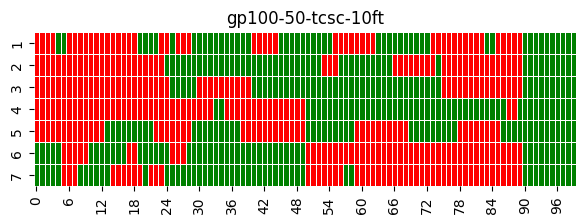

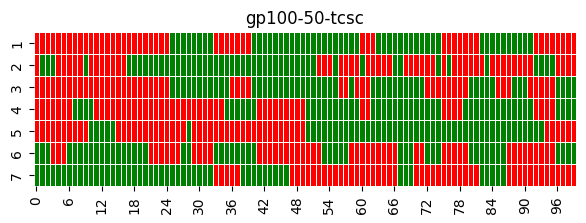

In [6]:
folder = 'availability_matrices/av-mat-8'

tmp = res[CORR_FT]
key_word = 'gp'+str(rounds) + '-'+ str(int(freq*100)) + '-tcsc-' + str(ft) + 'ft'
availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)
plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

# tmp = res[UNCORR_FT]
# key_word = 'gp'+str(rounds) + '-'+ str(int(freq*100)) + '-tusc-' + str(ft) + 'ft'
# availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)
# plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
# availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

tmp = res[CORR]
key_word = 'gp'+str(rounds) + '-'+ str(int(freq*100)) + '-tcsc'
availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)
plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

# tmp = res[UNCORR]
# key_word = 'gp'+str(rounds) + '-'+ str(int(freq*100)) + '-tusc'
# availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)
# plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
# availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)
